# préparation et extraction de features

In [51]:
from pathlib import Path
from PIL import Image
import numpy as np
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import seaborn as sns

# Importation des outils scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from radios_dataset import RadiosDataset

In [ ]:
# Détecte si tu on a une carte graphique Nvidia (cuda) ou Apple Silicon (mps), sinon reste sur cpu
# Dans mes tests passer du cpu au gpu (plus 4 workers dans le DataLoader,et pin_memory=True) fait gagner un facteur 18 sur le temps d'extraction des features !
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Calculs exécutés sur : {device}")

Calculs exécutés sur : cuda


In [53]:
def extraire_images(path):
    """ renvoie un tableau numpy contenant les images extraites du chemin donné """
    path_fichier_jpg = list(path.glob("*.jpg"))
    return np.array([np.array(Image.open(fichier)) for fichier in path_fichier_jpg])

In [54]:
# def extraire_features(modele, dataloader):
#     liste_features = []
    
#     with torch.no_grad():
#         # Le DataLoader nous donne les images batch_size par batch_size
#         for batch_images in tqdm(dataloader, desc="Extraction des features"):
            
#             # On extrait les vecteurs
#             features = modele(batch_images)
            
#             # On les ajoute à notre liste de résultats
#             liste_features.append(features)
            
#     # À la fin, on empile tous les vecteurs extraits
#     features_finales = torch.cat(liste_features, dim=0)
#     return features_finales

def extraire_features(modele, dataloader):
    liste_features = []
    
    with torch.no_grad():
        for batch_images in tqdm(dataloader, desc="Extraction des features"):
            
            # On envoie le lot d'images sur la carte graphique (là où se trouve ResNet)
            batch_images = batch_images.to(device)
            
            # On extrait les vecteurs
            features = modele(batch_images)
            
            # On ramène le résultat sur le CPU de l'ordinateur avant de le sauvegarder.
            # ça soulage la carte graphique
            liste_features.append(features.cpu())
            
    # On empile tout à la fin
    features_finales = torch.cat(liste_features, dim=0)
    return features_finales

In [55]:

# On définit les chemins
chemin_sans_label = Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/sans_label")
chemin_normal = Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/avec_labels/normal")
chemin_cancer = Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/avec_labels/cancer")

chemins_sans_label = list(Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/sans_label").glob("*.jpg"))
chemins_normal = list(Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/avec_labels/normal").glob("*.jpg"))
chemins_cancer = list(Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/avec_labels/cancer").glob("*.jpg"))

print(f"Nombre d'images sans label : {len(chemins_sans_label)}")
print(f"Nombre d'images normales : {len(chemins_normal)}")
print(f"Nombre d'images cancéreuses : {len(chemins_cancer)}")

# On récupère tous les fichiers png
images_sans_label = extraire_images(chemin_sans_label)
images_normal = extraire_images(chemin_normal)
images_cancer = extraire_images(chemin_cancer)

if len(images_sans_label) == 0 or len(images_normal) == 0 or len(images_cancer) == 0:
    print("Erreur : Aucun fichier trouvé dans l'un des dossiers.")

else:
    print(f"Succès : {len(images_sans_label)} images trouvées.")
    # On peut maintenant prendre la première en toute sécurité
    image_matrice = np.array(images_sans_label[0])     
    print(f"Forme de l'image : {image_matrice.shape}")


Nombre d'images sans label : 1406
Nombre d'images normales : 50
Nombre d'images cancéreuses : 50
Succès : 1406 images trouvées.
Forme de l'image : (512, 512, 3)


In [56]:
def verifier_format_images(images):
    """ verifie que toutes les images ont la même taille et le même nombre de canaux de couleur de base (512x512 pixels et 3 canaux) """
    memedimensions = True
    # On vérifie que toutes les images sont au même format
    for image in images:
        memeDimensions = True
        if np.array(image).shape != (512, 512, 3):
            print(f"Attention : L'image {image} a une taille différente : {image.size}")
            memedimensions = False
    if memedimensions:
        print("Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.")
    else:
        print("Il y a des images avec des tailles différentes. Veuillez vérifier les fichiers.")
    return memedimensions


In [57]:
# On vérifie que toutes les images sont bien au même format

verifier_format_images(images_sans_label)
verifier_format_images(images_normal)
verifier_format_images(images_cancer)

Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.
Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.
Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.


True

In [58]:
# Tailles de nos ensembles 
print(f"Nombre d'images sans label : {len(images_sans_label)}")
print(f"Nombre d'images normales : {len(images_normal)}")
print(f"Nombre d'images cancéreuses : {len(images_cancer)}")

Nombre d'images sans label : 1406
Nombre d'images normales : 50
Nombre d'images cancéreuses : 50


In [59]:
# Vérifications pour trouver des outliers
# -> On regroupe tout dans une même liste pour faire les vérifications d'un coup
toutes_les_images = np.concatenate([images_sans_label, images_normal, images_cancer])

# 1. On calcule la moyenne de CHAQUE image (le résultat sera une liste de 1506 moyennes)
moyennes_par_image = np.mean(toutes_les_images, axis=(1, 2, 3))

# 2. On calcule la moyenne et l'écart-type de ces 1506 valeurs
moyenne_des_moyennes = np.mean(moyennes_par_image)
ecart_type = np.std(moyennes_par_image)

print(f"Moyenne globale : {moyenne_des_moyennes}")
print(f"Écart-type global : {ecart_type}")

# 3. On calcule le "Z-score" (à combien d'écarts-types chaque image se trouve de la moyenne)
z_scores = np.abs((moyennes_par_image - moyenne_des_moyennes) / ecart_type)

# 4. On trouve les index des images qui dépassent le seuil de 3
index_outliers = np.where(z_scores > 3)[0]

print(f"Nombre d'outliers potentiels trouvés : {len(index_outliers)}")

Moyenne globale : 52.400531632861195
Écart-type global : 17.373623445055856
Nombre d'outliers potentiels trouvés : 14


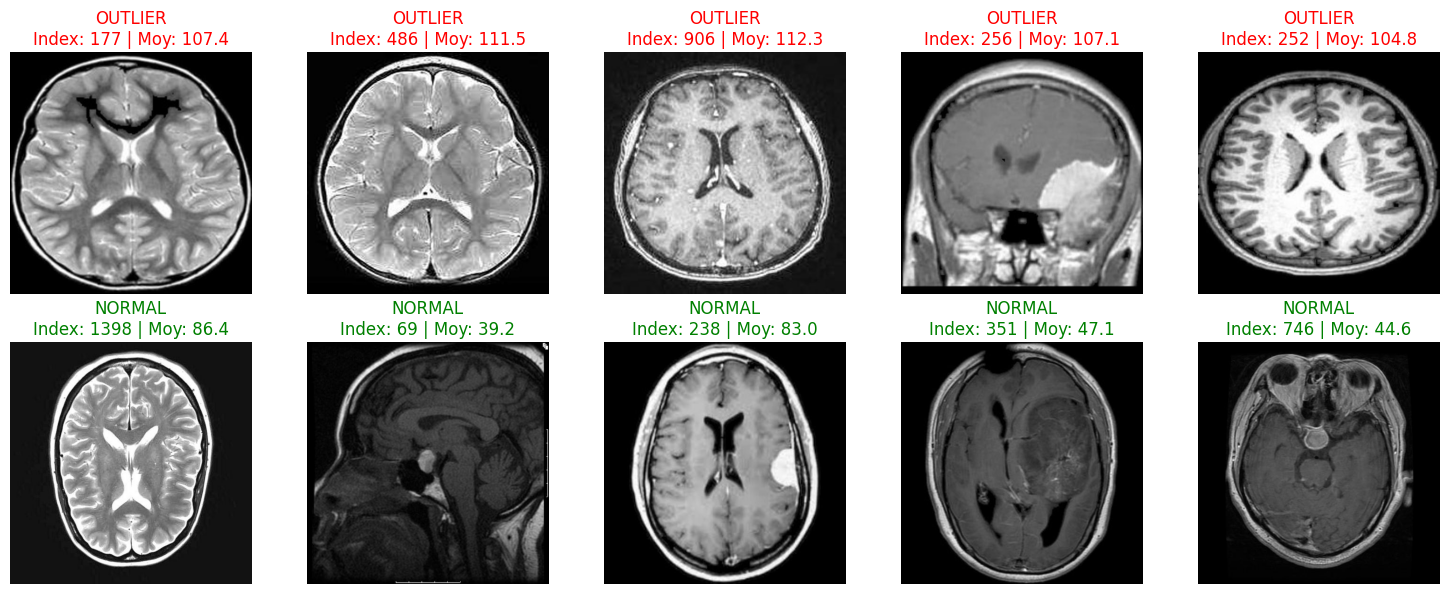

In [60]:
import matplotlib.pyplot as plt
import random

# 1. On liste tous les index "normaux" (ceux qui ne sont PAS dans tes 14 outliers)
tous_les_index = np.arange(len(toutes_les_images))
index_normaux = np.setdiff1d(tous_les_index, index_outliers)

# 2. On sélectionne un échantillon au hasard (ex: 5 images de chaque)
nb_a_afficher = 5
echantillon_outliers = random.sample(list(index_outliers), nb_a_afficher)
echantillon_normaux = random.sample(list(index_normaux), nb_a_afficher)

# 3. Création de la figure (2 lignes, 5 colonnes)
fig, axes = plt.subplots(nrows=2, ncols=nb_a_afficher, figsize=(15, 6))

# ---- LIGNE 1 : Affichage des Outliers ----
for i, idx in enumerate(echantillon_outliers):
    ax = axes[0, i]
    # On affiche l'image (si tes images sont en niveaux de gris, ajoute cmap='gray')
    ax.imshow(toutes_les_images[idx]) 
    
    # On ajoute un titre avec la valeur de la moyenne pour comprendre pourquoi c'est un outlier
    moyenne_img = moyennes_par_image[idx]
    ax.set_title(f"OUTLIER\nIndex: {idx} | Moy: {moyenne_img:.1f}", color='red')
    ax.axis('off') # On cache les axes (les graduations de pixels)

# ---- LIGNE 2 : Affichage des Normales ----
for i, idx in enumerate(echantillon_normaux):
    ax = axes[1, i]
    ax.imshow(toutes_les_images[idx])
    
    moyenne_img = moyennes_par_image[idx]
    ax.set_title(f"NORMAL\nIndex: {idx} | Moy: {moyenne_img:.1f}", color='green')
    ax.axis('off')

# Ajustement esthétique pour ne pas que les titres se chevauchent
plt.tight_layout()
plt.show()

Les outliers n'ont pas l'air d'être des erreurs mais juste des images plus clairs (peut-être due à un autre système d'imagerie ?)

# Clustering non supervisé

In [61]:
# Pipeline optimal pour garder 100% de la résolution
transformations_resnet = transforms.Compose([
    
    # Convertit le tableau NumPy (512, 512, 3) en Tenseur (3, 512, 512) et le met entre 0 et 1
    transforms.ToTensor(), 
    
    
    # Normalisation standard ImageNet. 
    # Même si ce sont des IRM, il faut garder ces valeurs précises car les "yeux" (poids)
    # du modèle pré-entraîné ont été habitués à cette luminosité exacte.
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [62]:
# 1. On charge ResNet50 avec ses poids pré-entraînés sur ImageNet
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# On envoie le modèle sur cette puce
resnet50 = resnet50.to(device)
# 2. On "coupe la tête" du modèle !
# La dernière couche de ResNet s'appelle 'fc' (Fully Connected) et sort 1000 probabilités.
# On la remplace par une couche "Identité" qui ne fait rien, pour récupérer le vecteur brut (de taille 2048).
resnet50.fc = nn.Identity()

# 3. On passe le modèle en mode évaluation (très important pour figer les couches comme BatchNorm)
resnet50.eval()


# 1. On crée les "recettes" pour tes trois dossiers
dataset_sans_label = RadiosDataset(chemins_sans_label, transformations_resnet)
dataset_normal = RadiosDataset(chemins_normal, transformations_resnet)
dataset_cancer = RadiosDataset(chemins_cancer, transformations_resnet)

BATCH_SIZE = 128

# 2. On crée les DataLoaders

dataloader_sans_label = DataLoader(dataset_sans_label, batch_size=BATCH_SIZE, shuffle=False, 
    num_workers=4, 
    pin_memory=True)
dataloader_normal = DataLoader(dataset_normal, batch_size=BATCH_SIZE, shuffle=False, 
    num_workers=4, 
    pin_memory=True)
dataloader_cancer = DataLoader(dataset_cancer, batch_size=BATCH_SIZE, shuffle=False, 
    num_workers=4, 
    pin_memory=True)


# On lance l'extraction !
print("Extraction des features sans label...")
features_sans_label = extraire_features(resnet50, dataloader_sans_label)

print("Extraction des features normal...")
features_normal = extraire_features(resnet50, dataloader_normal)

print("Extraction des features cancer...")
features_cancer = extraire_features(resnet50, dataloader_cancer)

print("Taille finale des features sans label :", features_sans_label.shape)

Extraction des features sans label...


Extraction des features:   0%|          | 0/11 [00:00<?, ?it/s]

Extraction des features normal...


Extraction des features:   0%|          | 0/1 [00:00<?, ?it/s]

Extraction des features cancer...


Extraction des features:   0%|          | 0/1 [00:00<?, ?it/s]

Taille finale des features sans label : torch.Size([1406, 2048])


Standardisation des features...
Calcul de la PCA intermédiaire (50 dimensions)...
Information conservée par ces 50 dimensions : 50.61%
Application de K-Means...
Calcul du t-SNE (Réduction en 2D pour le graphique)...
Génération du graphique...


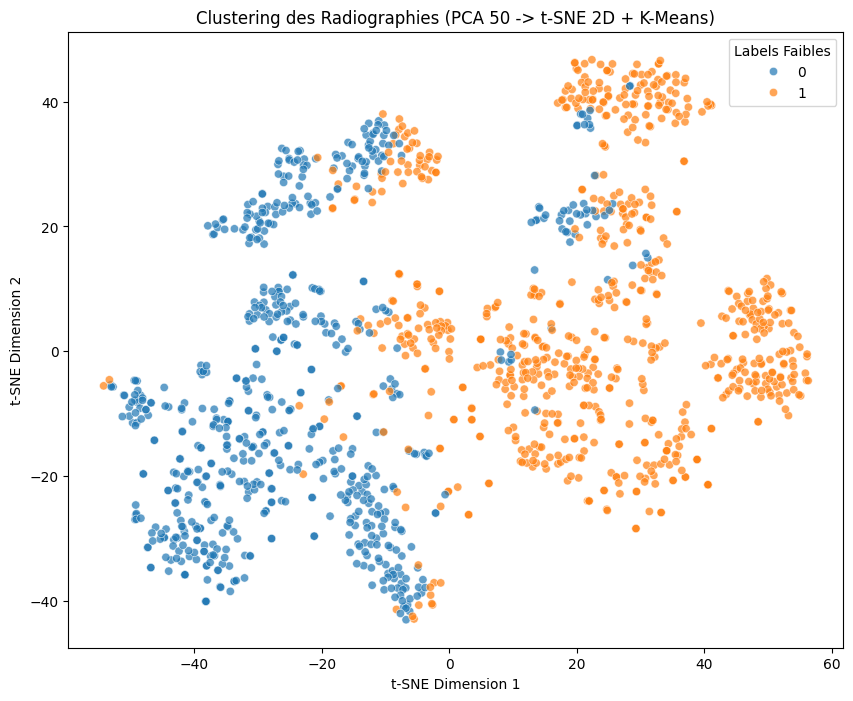

In [ ]:
from sklearn.manifold import TSNE
# ==========================================
# 1. STANDARDISATION
# ==========================================
print("Standardisation des features...")
features_sans_label_np = features_sans_label.numpy()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_sans_label_np) 

# ==========================================
# 2. RÉDUCTION INTERMÉDIAIRE (Pour le clustering)
# ==========================================
print("Calcul de la PCA intermédiaire (50 dimensions)...")
# On réduit à 50 dimensions pour "nettoyer" les données
pca_50 = PCA(n_components=50, random_state=42)
features_50d = pca_50.fit_transform(features_scaled)

variance_gardee = np.sum(pca_50.explained_variance_ratio_) * 100
print(f"Information conservée par ces 50 dimensions : {variance_gardee:.2f}%")

# ==========================================
# 3. CLUSTERING (Création des labels faibles)
# ==========================================
print("Application de K-Means...")
kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto")
# ASTUCE : On entraîne K-Means sur les 50 dimensions propres, c'est bien plus efficace !
labels_faibles = kmeans.fit_predict(features_50d)

# ==========================================
# 4. RÉDUCTION FINALE (Pour la visualisation)
# ==========================================
print("Calcul du t-SNE (Réduction en 2D pour le graphique)...")
# t-SNE va prendre les 50 dimensions et les compresser en 2 de manière non-linéaire
tsne = TSNE(n_components=2, random_state=42)
features_2d_tsne = tsne.fit_transform(features_50d)

# ==========================================
# 5. VISUALISATION DES RÉSULTATS
# ==========================================
print("Génération du graphique...")
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=features_2d_tsne[:, 0], # Axe X du t-SNE
    y=features_2d_tsne[:, 1], # Axe Y du t-SNE
    hue=labels_faibles, 
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.7 
)

plt.title("Clustering des Radiographies (PCA 50 -> t-SNE 2D + K-Means)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title='Labels Faibles')
plt.show()

In [ ]:
# --- CALCUL DU SCORE ARI ---
from sklearn.metrics import adjusted_rand_score


features_test = torch.cat((features_normal, features_cancer), dim=0).numpy()
vrais_labels = np.concatenate((np.zeros(len(features_normal)), np.ones(len(features_cancer))))

# 1. On standardise
features_test_scaled = scaler.transform(features_test)
# 2. On réduit à 50 dimensions avec la PCA déjà entraînée
features_test_50d = pca_50.transform(features_test_scaled)
# 3. On prédit avec K-Means
predictions_test = kmeans.predict(features_test_50d)

score_ari = adjusted_rand_score(vrais_labels, predictions_test)
print(f"-> Score ARI final : {score_ari:.4f}")

-> Score ARI final : 0.2642
